In [1]:
import os
import sys
sys.path.append("/home/amirabbas-kazeminia/Projects/DeepRT")

from Model.deeprt import DeepRT
model = DeepRT.load_from_checkpoint("/home/amirabbas-kazeminia/Projects/DeepRT/weights/1layers_2heads_24dim_10seed.ckpt")

In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import torch
def weighted_median(values, weights):
    """
    Compute the weighted median of given values and weights.
    """
    values = np.array(values)
    weights = np.array(weights)
    
    # Sort values and associated weights
    sorted_indices = np.argsort(values)
    values_sorted = values[sorted_indices]
    weights_sorted = weights[sorted_indices]
    
    # Compute cumulative weight and normalize
    cum_weights = np.cumsum(weights_sorted)
    total_weight = cum_weights[-1]
    
    # Find the index where cumulative weight >= 50%
    median_idx = np.searchsorted(cum_weights, 0.5 * total_weight)
    
    return values_sorted[median_idx]

/tmp/ipykernel_29525/1873109345.py:9: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  values = np.array(values)
/tmp/ipykernel_29525/1873109345.py:10: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  weights = np.array(weights)


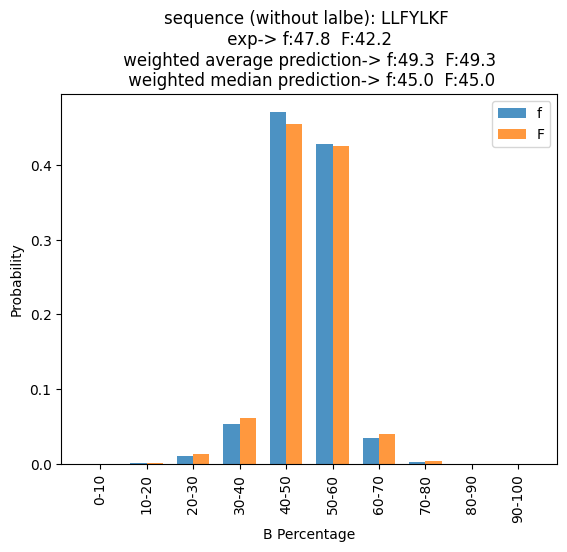

In [11]:
sequence = "LLFYLKF"
F = 42.2
f = 47.8
f_B_prbs = model.predict([f"f{sequence}"])["B_probs"].squeeze()[1:]
F_B_prbs = model.predict([f"F{sequence}"])["B_probs"].squeeze()[1:]
labels = [f"{i}-{i+10}" for i in range(0,100,10)]
x = np.arange(len(labels))
f_pred = (torch.arange(5,100,10) * f_B_prbs).sum()
f_med = weighted_median(torch.arange(5,100,10), f_B_prbs)
F_med = weighted_median(torch.arange(5,100,10), F_B_prbs)
F_pred = (torch.arange(5,100,10) * F_B_prbs).sum()
width = 0.35

plt.bar(x-width/2, f_B_prbs, width, label='f', alpha=0.8)
plt.bar(x+width/2, F_B_prbs, width, label='F', alpha=0.8)
plt.xticks(x,labels, rotation=90)
plt.title(f"sequence (without lalbe): {sequence} \n exp-> f:{f}  F:{F} \n weighted average prediction-> f:{f_pred:.1f}  F:{F_pred:.1f} \n weighted median prediction-> f:{f_med:.1f}  F:{F_med:.1f}")
plt.xlabel("B Percentage")
plt.ylabel("Probability")
plt.legend()
plt.show()

In [36]:
print("fLLFYLKF: ")
print(model.predict("fLLFYLKF")[0])
print("FLLFYLKF: ")
print(model.predict("FLLFYLKF")[0])

fLLFYLKF: 
  Feature   Prediction  Probability   Entropy
0       B  45.00-50.00     0.294253  1.842538
1       B  40.00-45.00     0.232266  1.842538
2       B  50.00-55.00     0.185743  1.842538
FLLFYLKF: 
  Feature   Prediction  Probability   Entropy
0       B  40.00-45.00     0.395404  1.578118
1       B  45.00-50.00     0.279026  1.578118
2       B  35.00-40.00     0.160190  1.578118


fEQFGSHTMADACHKF,16.2
FEQFGSHTMADACHKF,19.42856388888889

/tmp/ipykernel_29525/1873109345.py:9: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  values = np.array(values)
/tmp/ipykernel_29525/1873109345.py:10: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  weights = np.array(weights)


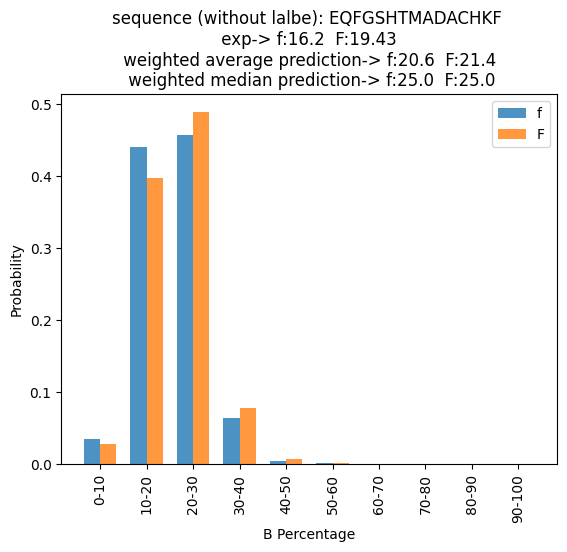

In [12]:
sequence = "EQFGSHTMADACHKF"
F = 19.43
f = 16.2
f_B_prbs = model.predict([f"f{sequence}"])["B_probs"].squeeze()[1:]
F_B_prbs = model.predict([f"F{sequence}"])["B_probs"].squeeze()[1:]
labels = [f"{i}-{i+10}" for i in range(0,100,10)]
x = np.arange(len(labels))
f_pred = (torch.arange(5,100,10) * f_B_prbs).sum()
f_med = weighted_median(torch.arange(5,100,10), f_B_prbs)
F_med = weighted_median(torch.arange(5,100,10), F_B_prbs)
F_pred = (torch.arange(5,100,10) * F_B_prbs).sum()
width = 0.35

plt.bar(x-width/2, f_B_prbs, width, label='f', alpha=0.8)
plt.bar(x+width/2, F_B_prbs, width, label='F', alpha=0.8)
plt.xticks(x,labels, rotation=90)
plt.title(f"sequence (without lalbe): {sequence} \n exp-> f:{f}  F:{F} \n weighted average prediction-> f:{f_pred:.1f}  F:{F_pred:.1f} \n weighted median prediction-> f:{f_med:.1f}  F:{F_med:.1f}")
plt.xlabel("B Percentage")
plt.ylabel("Probability")
plt.legend()
plt.show()

In [8]:
print("fEQFGSHTMADACHKF: ")
print(model.predict("fEQFGSHTMADACHKF"))
print("FEQFGSHTMADACHKF: ")
print( model.predict("FEQFGSHTMADACHKF"))

fEQFGSHTMADACHKF: 
  Feature   Prediction  Probability   Entropy
0       B  15.00-20.00     0.377585  1.511186
1       B  20.00-25.00     0.298514  1.511186
2       B  25.00-30.00     0.131856  1.511186
FEQFGSHTMADACHKF: 
  Feature   Prediction  Probability  Entropy
0       B  15.00-20.00     0.369154  1.47472
1       B  20.00-25.00     0.320198  1.47472
2       B  25.00-30.00     0.142335  1.47472


fAHNSWKF,14.24958777777778
FAHNSWKF,12.838722222222223

/tmp/ipykernel_29525/1873109345.py:9: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  values = np.array(values)
/tmp/ipykernel_29525/1873109345.py:10: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  weights = np.array(weights)


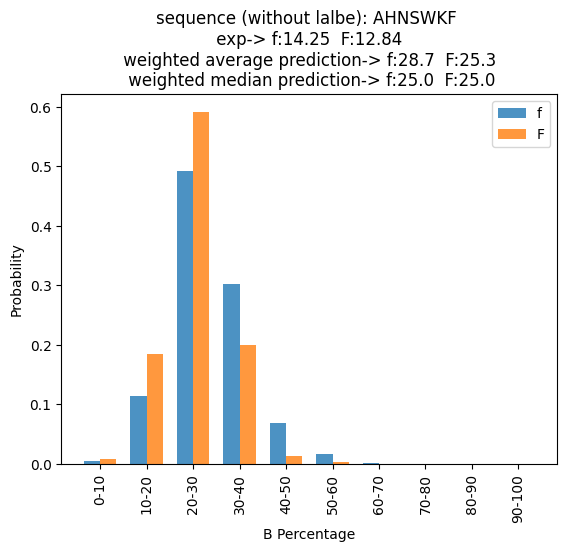

In [13]:
sequence = "AHNSWKF"
F = 12.84
f = 14.25
f_B_prbs = model.predict([f"f{sequence}"])["B_probs"].squeeze()[1:]
F_B_prbs = model.predict([f"F{sequence}"])["B_probs"].squeeze()[1:]
labels = [f"{i}-{i+10}" for i in range(0,100,10)]
x = np.arange(len(labels))
f_pred = (torch.arange(5,100,10) * f_B_prbs).sum()
f_med = weighted_median(torch.arange(5,100,10), f_B_prbs)
F_med = weighted_median(torch.arange(5,100,10), F_B_prbs)
F_pred = (torch.arange(5,100,10) * F_B_prbs).sum()
width = 0.35

plt.bar(x-width/2, f_B_prbs, width, label='f', alpha=0.8)
plt.bar(x+width/2, F_B_prbs, width, label='F', alpha=0.8)
plt.xticks(x,labels, rotation=90)
plt.title(f"sequence (without lalbe): {sequence} \n exp-> f:{f}  F:{F} \n weighted average prediction-> f:{f_pred:.1f}  F:{F_pred:.1f} \n weighted median prediction-> f:{f_med:.1f}  F:{F_med:.1f}")
plt.xlabel("B Percentage")
plt.ylabel("Probability")
plt.legend()
plt.show()

In [9]:
print("fAHNSWKF: ")
print(model.predict("fAHNSWKF"))
print("FAHNSWKF: ")
print( model.predict("FAHNSWKF"))

fAHNSWKF: 
  Feature   Prediction  Probability   Entropy
0       B  15.00-20.00     0.478835  0.948324
1       B  10.00-15.00     0.452867  0.948324
2       B  20.00-25.00     0.041795  0.948324
FAHNSWKF: 
  Feature   Prediction  Probability   Entropy
0       B  10.00-15.00     0.662687  0.885355
1       B  15.00-20.00     0.230867  0.885355
2       B   5.00-10.00     0.097224  0.885355


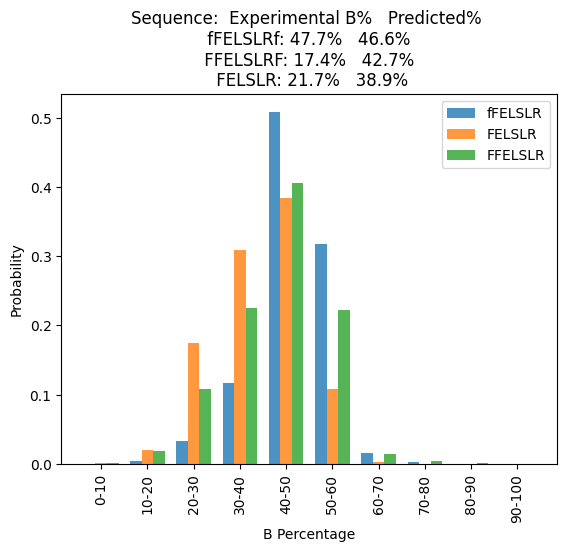

In [29]:
sequence = "FELSLR"
F = 25.0
f = 23.7
_ = 16.6
f_B_prbs = model.predict(['f'+sequence])["B_probs"].squeeze()[1:]
F_B_prbs = model.predict(['F'+sequence])["B_probs"].squeeze()[1:]
_B_prbs = model.predict([sequence])["B_probs"].squeeze()[1:]
labels = [f"{i}-{i+10}" for i in range(0,100,10)]
x = np.arange(len(labels))
f_pred = (torch.arange(5,100,10) * f_B_prbs).sum()
# f_med = weighted_median(torch.arange(5,100,10), f_B_prbs)
# F_med = weighted_median(torch.arange(5,100,10), F_B_prbs)
F_pred = (torch.arange(5,100,10) * F_B_prbs).sum()
_pred = (torch.arange(5,100,10) * _B_prbs).sum()
width = 0.25

plt.bar(x-width, f_B_prbs, width, label='fFELSLR', alpha=0.8)
plt.bar(x, _B_prbs, width, label='FELSLR', alpha=0.8)
plt.bar(x+width, F_B_prbs, width, label='FFELSLR', alpha=0.8)

plt.xticks(x,labels, rotation=90)
plt.title(f"Sequence:  Experimental B%   Predicted% \n f{sequence}f: 47.7%   {f_pred:.1f}% \n F{sequence}F: 17.4%   {F_pred:.1f}% \n {sequence}: 21.7%   {_pred:.1f}%")
plt.xlabel("B Percentage")
plt.ylabel("Probability")
plt.legend()
plt.show()

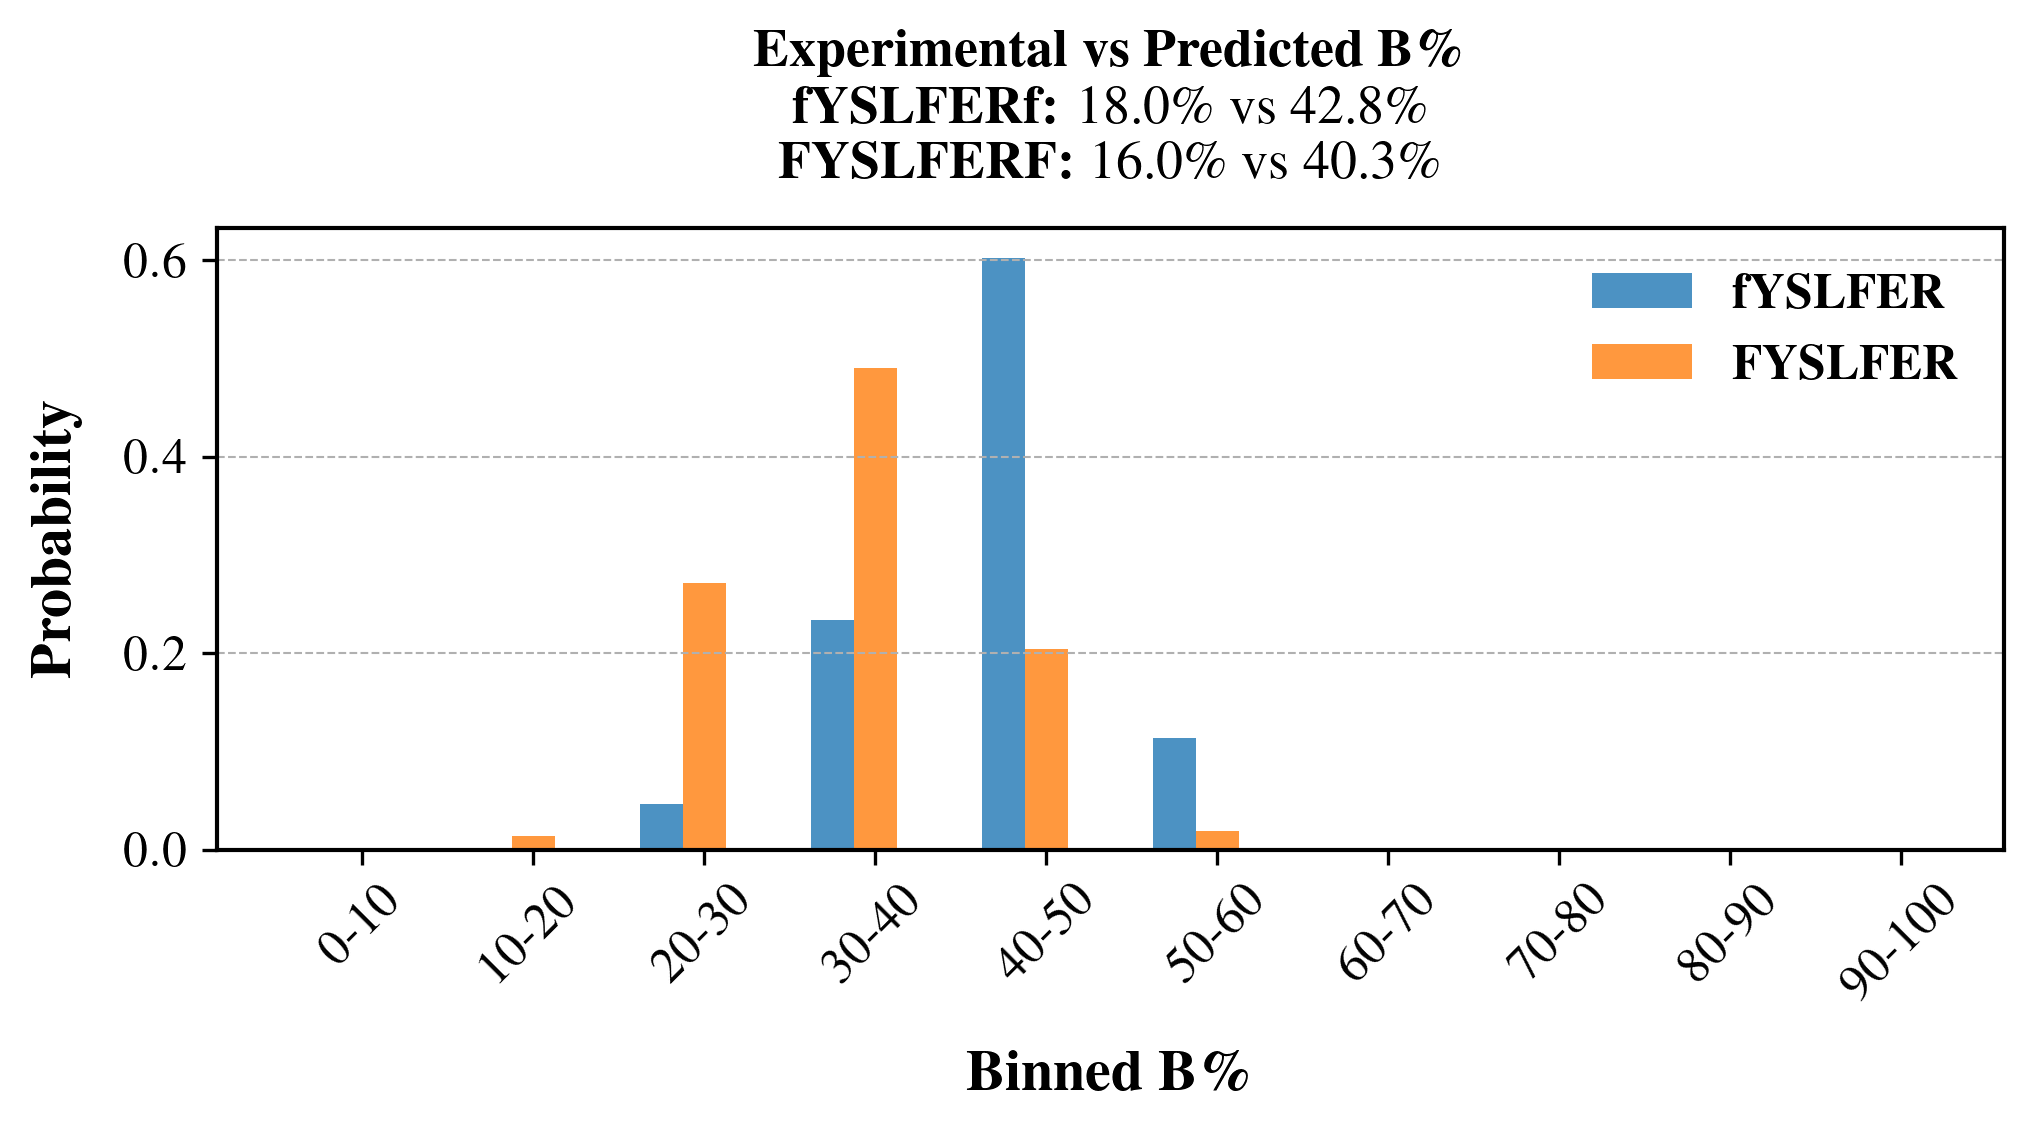

In [46]:
import numpy as np
import matplotlib.pyplot as plt
import torch

# Sequence and predictions
sequence = "YSLFER"
F = 16
f = 18
_ = 16.6

f_B_prbs = model.predict(['f'+sequence])["B_probs"].squeeze()[1:]
F_B_prbs = model.predict(['F'+sequence])["B_probs"].squeeze()[1:]
_B_prbs   = model.predict([sequence])["B_probs"].squeeze()[1:]

labels = [f"{i}-{i+10}" for i in range(0,100,10)]
x = np.arange(len(labels))
width = 0.25

f_pred = (torch.arange(5,100,10) * f_B_prbs).sum()
F_pred = (torch.arange(5,100,10) * F_B_prbs).sum()
_pred  = (torch.arange(5,100,10) * _B_prbs).sum()

# --- LaTeX-style settings for publication ---
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Times"],
    "axes.labelsize": 14,
    "font.size": 14,
    "legend.fontsize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "figure.dpi": 300,
    "axes.linewidth": 1.0
})

# --- Create figure ---
fig, ax = plt.subplots(figsize=(7, 4))

ax.bar(x - width, f_B_prbs, width=width, label=r'\textbf{fYSLFER}', alpha=0.8)
ax.bar(x, _B_prbs, width=width, label=r'\textbf{FYSLFER}', alpha=0.8)
# ax.bar(x + width, F_B_prbs, width=width, label=r'\textbf{FFELSLR}', alpha=0.8)

ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45)
ax.set_xlabel(r'\textbf{Binned B\%}', labelpad=10)
ax.set_ylabel(r'\textbf{Probability}', labelpad=10)

ax.set_title(
    # rf"\textbf{{Sequence:}} \texttt{{{sequence}}} \quad "
    rf"\textbf{{Experimental vs Predicted B\%}}" "\n"
    rf"\textbf{{f{sequence}f:}} {f:.1f}\% vs {f_pred:.1f}\%"  "\n"
    rf"\textbf{{F{sequence}F:}} {F:.1f}\% vs {F_pred:.1f}\% \quad ",
    # rf"\textbf{{{sequence}:}} {_:.1f}\% vs {_pred:.1f}\%",
    fontsize=13, pad=12
)

ax.legend(loc='upper right', frameon=False)
ax.grid(axis='y', linestyle='--', linewidth=0.5)

plt.tight_layout()
# plt.savefig("/home/amirabbas-kazeminia/Projects/DeepRT/figures/example.pdf", format="pdf")
plt.show()


/tmp/ipykernel_29525/1873109345.py:9: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  values = np.array(values)
/tmp/ipykernel_29525/1873109345.py:10: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  weights = np.array(weights)


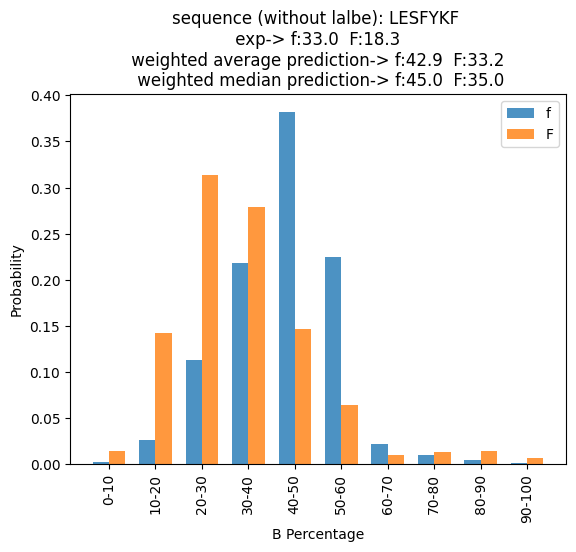

In [15]:
sequence = "LESFYKF"
F = 18.3
f = 33.0
f_B_prbs = model.predict([f"f{sequence}"])["B_probs"].squeeze()[1:]
F_B_prbs = model.predict([f"F{sequence}"])["B_probs"].squeeze()[1:]
labels = [f"{i}-{i+10}" for i in range(0,100,10)]
x = np.arange(len(labels))
f_pred = (torch.arange(5,100,10) * f_B_prbs).sum()
f_med = weighted_median(torch.arange(5,100,10), f_B_prbs)
F_med = weighted_median(torch.arange(5,100,10), F_B_prbs)
F_pred = (torch.arange(5,100,10) * F_B_prbs).sum()
width = 0.35

plt.bar(x-width/2, f_B_prbs, width, label='f', alpha=0.8)
plt.bar(x+width/2, F_B_prbs, width, label='F', alpha=0.8)
plt.xticks(x,labels, rotation=90)
plt.title(f"sequence (without lalbe): {sequence} \n exp-> f:{f}  F:{F} \n weighted average prediction-> f:{f_pred:.1f}  F:{F_pred:.1f} \n weighted median prediction-> f:{f_med:.1f}  F:{F_med:.1f}")
plt.xlabel("B Percentage")
plt.ylabel("Probability")
plt.legend()
plt.show()

/tmp/ipykernel_25924/1873109345.py:9: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  values = np.array(values)
/tmp/ipykernel_25924/1873109345.py:10: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  weights = np.array(weights)


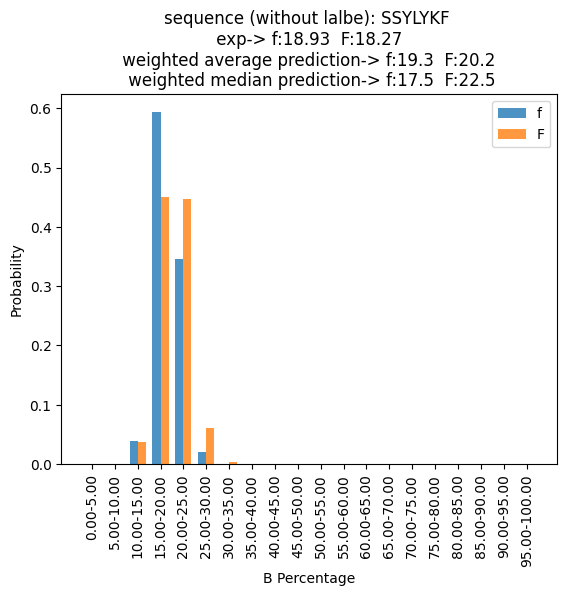

In [66]:
sequence = "SSYLYKF"
F = 18.27
f = 18.93
_, labels, f_B_prbs = model.predict(f"f{sequence}")
_, labels, F_B_prbs = model.predict(f"F{sequence}")
x = np.arange(len(labels))
f_pred = (torch.arange(2.5,100,5) * f_B_prbs).sum()
f_med = weighted_median(torch.arange(2.5,100,5), f_B_prbs)
F_med = weighted_median(torch.arange(2.5,100,5), F_B_prbs)
F_pred = (torch.arange(2.5,100,5) * F_B_prbs).sum()
width = 0.35

plt.bar(x-width/2, f_B_prbs, width, label='f', alpha=0.8)
plt.bar(x+width/2, F_B_prbs, width, label='F', alpha=0.8)
plt.xticks(x,labels, rotation=90)
plt.title(f"sequence (without lalbe): {sequence} \n exp-> f:{f}  F:{F} \n weighted average prediction-> f:{f_pred:.1f}  F:{F_pred:.1f} \n weighted median prediction-> f:{f_med:.1f}  F:{F_med:.1f}")
plt.xlabel("B Percentage")
plt.ylabel("Probability")
plt.legend()
plt.show()

In [54]:
import pandas as pd
import torch

data = pd.read_csv("/home/amirabbas-kazeminia/Projects/DeepRT_test/Data/ML_DATA.csv")
data_ = data.T.to_dict()
mapping = {datapoint["sequences"]:datapoint['B'] for datapoint in data_.values()}
sequences = data["sequences"].to_list()
L_F_seq_wo_L = []
L_F_seq = []
D_F_seq_wo_L = []
D_F_seq = []
for seq in sequences:
    if seq[0]=='f':
        D_F_seq.append(seq)
        D_F_seq_wo_L.append(seq[1:])
    elif seq[0]=='F':
        L_F_seq.append(seq)
        L_F_seq_wo_L.append(seq[1:])

intersection_ = list(set(L_F_seq_wo_L) & set(D_F_seq_wo_L))
intersection = []
for seq in intersection_:
    if abs(mapping['F'+seq]-mapping['f'+seq])>3:
        intersection.append(seq)
delta = np.array([(mapping['F'+seq]-mapping['f'+seq]>0)*1 for seq in intersection])

In [55]:
len(delta)

1712

In [56]:
average_delta = []
median_delta = []
for seq in intersection:
    _, _, F_B_prob = model.predict(f"F{seq}")
    _, _, f_B_prob = model.predict(f"f{seq}")
    average = ((torch.arange(2.5,100,5) * F_B_prob).sum()-(torch.arange(2.5,100,5) * f_B_prob).sum()).item()
    median = (weighted_median(torch.arange(2.5,100,5), F_B_prob)-weighted_median(torch.arange(2.5,100,5), f_B_prob)).item()
    average_delta.append(average)
    median_delta.append(median)

/tmp/ipykernel_31589/1873109345.py:9: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  values = np.array(values)
/tmp/ipykernel_31589/1873109345.py:10: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  weights = np.array(weights)


In [57]:
average_delta_labels = np.array([(el>0)*1 for el in average_delta])
median_delta_labels = np.array([(el>0)*1 for el in median_delta])

In [58]:
average_acc = ((average_delta_labels==delta).sum())/len(delta)
average_acc

np.float64(0.7949766355140186)

In [59]:
median_acc = ((median_delta_labels==delta).sum())/len(delta)
median_acc

np.float64(0.7424065420560748)